In [246]:
"""
Constructs the DFT of the dihedral group in SageMath using knowledge of the representation theory.

TO-DO: work over finite field.

notes: # Gershgorin's theorem did not provide good bounds for the eigenvalues.

""";

In [247]:
# ── Configuration ──────────────────────────────────────────────────────────────
n = 3; print("n =", n)
USE_FINITE_FIELD = True
p = 17; print("p =", p) # characteristic of the finite field
q = 17; print("q =", q) # size of the finite field

n = 3
p = 17
q = 17


In [248]:
# ── Build the coefficient ring and choose omega ─────────────────────────────────
if USE_FINITE_FIELD:
    # Find the smallest k such that n | (q^k - 1),
    # i.e. the multiplicative order of q mod n.
    k = Zmod(n)(q).multiplicative_order()
    F = GF(q**k, 'a')
    print(f"Working in GF({q}^{k}) = GF({q**k})")

    # Find a primitive n-th root of unity in F.
    # The multiplicative group of GF(q^k) is cyclic of order q^k - 1,
    # so a generator g satisfies g^((q^k-1)/n) has order n.
    g = F.multiplicative_generator()
    omega = g**((q**k - 1) // n)
    assert omega**n == F.one(), "omega is not an n-th root of unity"
    assert omega**(n-1) != F.one() or n == 1, "omega is not primitive"
    print(f"omega = {omega}  (order {omega.multiplicative_order()})")
else:
    K.<z> = CyclotomicField(n) #cyclotomic field containing a primitive n-th root of unity
    omega = z; print(f"omega = {omega}  (primitive n-th root of unity)")

Working in GF(17^2) = GF(289)
omega = 12*a + 2  (order 3)


In [249]:
G = DihedralGroup(n); print("G =", G) #D_n, dihedral group of order 2n
r = [g for g in G if g.order() == n][0] #rotation of order n, generator
s = [g for g in G if g.order() == 2 and g != r**(n//2)][0] #flip of order 2, generator
print("r =", r)
print("s =", s)

G = Dihedral group of order 6 as a permutation group
r = (1,3,2)
s = (2,3)


In [250]:
# returns (0, k) if g = r^k and (1, k) if g = s*r^k
def express_in_gens(g):
    for k in range(n):
        if g == r**k:
            return (0, k)
    for k in range(n):
        if g == s * r**k:
            return (1, k)

In [251]:
# n odd, we have two 1-dim'l irreps and (n-1)/2 2-dim'l irreps
# the 1-dim's irreps are trivial and sign
# the 2-dim'l irreps are given by rotation matrices and a flip matrix
def rho_odd(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:
        return matrix([1])
    if k == -1:
        if s_exp == 0:
            return matrix([1])
        if s_exp == 1:
            return matrix([-1])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(k*r_exp)], [omega**(-k*r_exp), 0]])

In [252]:
def dft_matrix_odd(omega):
    assert n % 2 == 1
    rows = []
    for g in G:
        row = [rho_odd(k, g, omega).list() for k in range(-1,(n-1)//2 + 1)]
        rows.append(sum(row, []))
    return matrix(rows)

In [253]:
# for n even case
def rho_even(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:   # trivial
        return matrix([1])
    if k == -1:  # sign of rotation
        return matrix([(-1)**r_exp])
    if k == -2:  # sign of reflection
        return matrix([(-1)**s_exp])
    if k == -3:  # total sign
        return matrix([(-1)**(r_exp + s_exp)])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(k*r_exp)], [omega**(-k*r_exp), 0]])

In [254]:
# form the DFT matrix for n even
def dft_matrix_even(omega):
    assert n % 2 == 0
    rows = []
    for g in G:
        row = [rho_even(k, g, omega).list() for k in range(-3, n//2)]
        rows.append(sum(row, []))
    return matrix(rows)

In [255]:
DFT_matrix = dft_matrix_odd(omega) if n % 2 == 1 else dft_matrix_even(omega); print(DFT_matrix)

[       1        1        1        0        0        1]
[       1        1 12*a + 2        0        0 5*a + 14]
[       1        1 5*a + 14        0        0 12*a + 2]
[      16        1        0        1        1        0]
[      16        1        0 12*a + 2 5*a + 14        0]
[      16        1        0 5*a + 14 12*a + 2        0]


In [256]:
f = DFT_matrix.charpoly(); print(f)

x^6 + (7*a + 3)*x^5 + (13*a + 2)*x^4 + (9*a + 11)*x^3 + (a + 11)*x^2 + (7*a + 6)*x + 14


In [257]:
if USE_FINITE_FIELD:
    L.<a> = f.splitting_field(); print(L)

Finite Field in a of size 17^8


In [258]:
R_L.<x> = PolynomialRing(L)
f_L = R_L(f)
f_L.factor()

(x + 14*a^6 + 8*a^5 + 16*a^4 + 13*a^3 + 4*a^2 + 14*a + 1) * (x + a^6 + 3*a^5 + 6*a^4 + 7*a^3 + 10*a^2 + a + 14) * (x + 13*a^7 + 16*a^6 + 10*a^5 + 16*a^4 + a^3 + 15*a^2 + 14*a + 8) * (x + 13*a^7 + 12*a^6 + 12*a^5 + 9*a^4 + 8*a^3 + 15*a^2 + 9*a + 10) * (x + 2*a^7 + 3*a^6 + 4*a^5 + 2*a^4 + 13*a^3 + 9*a^2 + 10*a + 11) * (x + 6*a^7 + 15*a^6 + 10*a^5 + 11*a^4 + 11*a^3 + 13*a^2 + 13*a + 16)

In [259]:
if USE_FINITE_FIELD:
    eigenvalues = f.roots(L, multiplicities=False)
    print(eigenvalues)
    print(len(eigenvalues))

[3*a^6 + 9*a^5 + a^4 + 4*a^3 + 13*a^2 + 3*a + 16, 16*a^6 + 14*a^5 + 11*a^4 + 10*a^3 + 7*a^2 + 16*a + 3, 4*a^7 + a^6 + 7*a^5 + a^4 + 16*a^3 + 2*a^2 + 3*a + 9, 4*a^7 + 5*a^6 + 5*a^5 + 8*a^4 + 9*a^3 + 2*a^2 + 8*a + 7, 15*a^7 + 14*a^6 + 13*a^5 + 15*a^4 + 4*a^3 + 8*a^2 + 7*a + 6, 11*a^7 + 2*a^6 + 7*a^5 + 6*a^4 + 6*a^3 + 4*a^2 + 4*a + 1]
6


In [260]:
def frobenius(x, p):
    return x**p

In [261]:
def frobenius_orbit(alpha, p):
    orbit = []
    seen = set()
    
    x = alpha
    while x not in seen:
        seen.add(x)
        orbit.append(x)
        x = x^p
    
    return orbit

In [262]:
def frobenius_orbits(eigenvalues, p):
    orbits = []
    seen = set()
    
    for lam in eigenvalues:
        if lam not in seen:
            orb = frobenius_orbit(lam, p)
            orbits.append(orb)
            seen.update(orb)
    
    return orbits

In [263]:
def discrete_log_Fq(x, alpha=None):
    F = x.parent()
    if x == 0:
        raise ValueError("Log undefined for 0")
    if alpha is None:
        alpha = F.multiplicative_generator()
    return x.log(alpha)

In [264]:
frobenius_orbits(eigenvalues, p)

[[3*a^6 + 9*a^5 + a^4 + 4*a^3 + 13*a^2 + 3*a + 16,
  14*a^6 + 8*a^5 + 16*a^4 + 13*a^3 + 4*a^2 + 14*a + 6],
 [16*a^6 + 14*a^5 + 11*a^4 + 10*a^3 + 7*a^2 + 16*a + 3,
  a^6 + 3*a^5 + 6*a^4 + 7*a^3 + 10*a^2 + a + 12],
 [4*a^7 + a^6 + 7*a^5 + a^4 + 16*a^3 + 2*a^2 + 3*a + 9,
  9*a^7 + 16*a^6 + a^5 + 4*a^4 + 16*a^3 + 4*a^2 + 13*a + 11,
  11*a^7 + 2*a^6 + 7*a^5 + 6*a^4 + 6*a^3 + 4*a^2 + 4*a + 1,
  5*a^7 + 9*a^5 + 11*a^4 + 15*a^3 + 6*a^2 + 2*a + 12,
  4*a^7 + 5*a^6 + 5*a^5 + 8*a^4 + 9*a^3 + 2*a^2 + 8*a + 7,
  10*a^7 + 4*a^6 + 14*a^5 + 5*a^4 + 6*a^3 + 2*a^2 + 15*a + 13,
  15*a^7 + 14*a^6 + 13*a^5 + 15*a^4 + 4*a^3 + 8*a^2 + 7*a + 6,
  10*a^7 + 9*a^6 + 12*a^5 + a^4 + 13*a^3 + 6*a^2 + 16*a + 10]]

In [265]:
len(frobenius_orbit(eigenvalues[0], p))

2

In [266]:
dlogs = [discrete_log_Fq(x, alpha=None) for x in eigenvalues]; dlogs

[1380618660, 6442887080, 6145486975, 985203775, 5693593375, 4203346015]

In [267]:
def brauer_map(x):
    if x == 0:
        return 0
    else:
        l = discrete_log_Fq(x, alpha=None)
        return exp(2 * pi * I * l / (L.order()-1))

In [268]:
complex_eigs = [brauer_map(eig) for eig in eigenvalues]; complex_eigs
eigs_num = [complex(e.n(digits=30)) for e in complex_eigs]; eigs_num

[(0.3214394653031616+0.9469301294951057j),
 (0.8870108331782217-0.4617486132350339j),
 (0.7331602080667159-0.6800559604235301j),
 (0.6314379833697753+0.7754263815204583j),
 (0.40403989048909855-0.9147413661213519j),
 (-0.7994400614386614-0.6007458598833197j)]

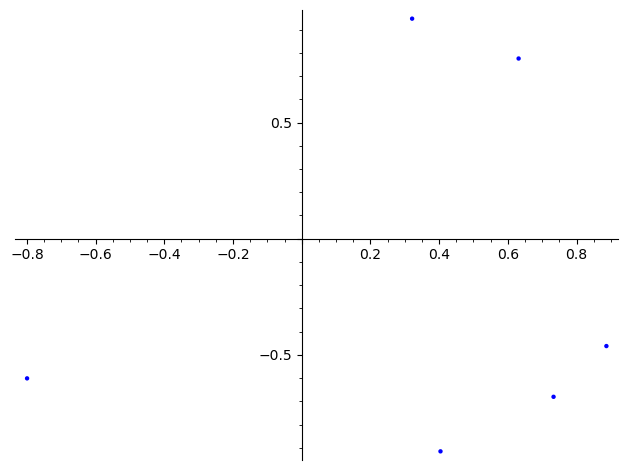

In [269]:
P = list_plot(
    [(z.real, z.imag) for z in eigs_num],
    plotjoined=False,
    marker='o'
)

P.show()

In [270]:
# can normalize by 1/sqrt(D) to get a unitary matrix
if not USE_FINITE_FIELD:
    print(DFT_matrix.conjugate_transpose() * DFT_matrix)

In [271]:
# form norm polynomial by acting on coefficients of characteristic polynomial by the Galois group
def norm_poly(f, n):

    def sigma(i):
        phi = K.hom([z**i])
        return f.map_coefficients(phi)
    
    units = [i for i in range(1, n) if gcd(i, n) == 1]  # (Z/nZ)^×
    result = prod(sigma(i) for i in units)
    return result.change_ring(QQ)

In [272]:
f = DFT_matrix.charpoly(); f

x^6 + (7*a + 3)*x^5 + (13*a + 2)*x^4 + (9*a + 11)*x^3 + (a + 11)*x^2 + (7*a + 6)*x + 14

In [291]:
if not USE_FINITE_FIELD:
    Nf = norm_poly(f, n); Nf

In [ ]:
if not USE_FINITE_FIELD:
    Nf.is_irreducible()

False

In [ ]:
if not USE_FINITE_FIELD:
    Nf.factor()

(x^6 + 5*x^5 + 5*x^4 + 3*x^3 + 10*x^2 + x + 11)^2

In [ ]:
if not USE_FINITE_FIELD:
    Nf.galois_group()

ValueError: The polynomial must be irreducible

In [ ]:
if not USE_FINITE_FIELD:
    G = TransitiveGroup(12, 299)
    print(G.order())
    print(G.is_solvable())
    print(G.is_primitive())
    print(G.structure_description())

1036800
False
False
(A6 x A6) : D4
